In [1]:
import numpy as np
from PIL import Image
import json
import os
import tempfile
from panopticapi.evaluation_debug import pq_compute as pq_compute_debug
from helpers import create_panoptic_test_data

def panopticapi_results(pred, ref, stuff_cls_list, thing_cls_list):
    """
    Compute panoptic quality using panopticapi
    """
    # Create a dummy dataset
    data_paths = create_panoptic_test_data(pred, ref, stuff_cls_list, thing_cls_list)

    # Run evaluation
    print("Overall results:")
    pq_compute_debug(
        gt_json_file=data_paths["gt_json"],
        pred_json_file=data_paths["pred_json"],
        gt_folder=data_paths["gt_folder"],
        pred_folder=data_paths["pred_folder"]
    )

    # print("Results:")
    # for key, value in results.items():
    #     if key == 'per_class':
    #         continue
    #     print(f"{key}: {value}")

    # # Print per-class details in a more readable format
    # print("\nPer-class results (non-zero scores only):")
    # print("{:^10}|{:^8}{:^8}{:^8}".format("Class ID", "PQ", "SQ", "RQ"))
    # print("-" * 34)

    # # Get per-class results and filter out zero scores
    # per_class = results['per_class']
    # non_zero_classes = {class_id: metrics for class_id, metrics in per_class.items() 
    #                 if metrics['pq'] > 0}

    # # Print classes with non-zero scores
    # for class_id, metrics in sorted(non_zero_classes.items()):
    #     print("{:^10}|{:^8.1f}{:^8.1f}{:^8.1f}".format(
    #         class_id,
    #         metrics['pq'] * 100,
    #         metrics['sq'] * 100,
    #         metrics['rq'] * 100
    #     ))

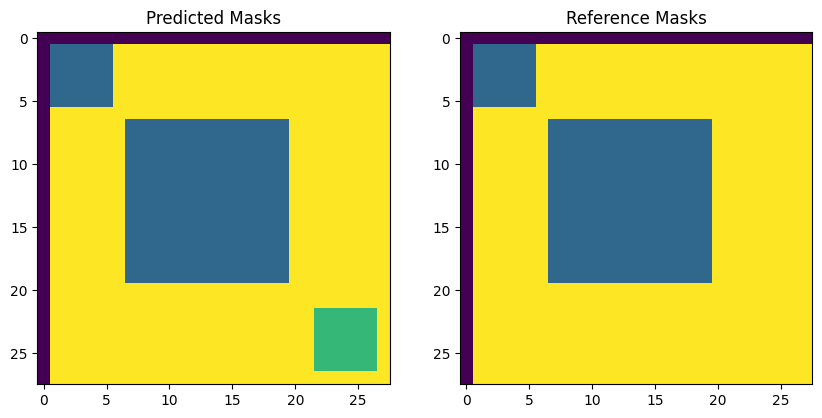

Overall results:
          |    PQ     SQ     RQ     N
--------------------------------------
All       |  65.1   65.1   66.7     3
Things    |  50.0   50.0   50.0     2
Stuff     |  95.3   95.3  100.0     1

Total counts:
TP: 3
FP: 1
FN: 0
Numerator (sum of IoU): 2.9533
Denominator (TP + 0.5*FP + 0.5*FN): 3.5000
Raw PQ (before averaging): 0.8438

=== DETAILED CALCULATION BREAKDOWN ===
The final PQ score is an average of the PQ scores across all categories.
For each category, PQ = IoU / (TP + 0.5*FP + 0.5*FN)

Per-category statistics:
Category                      |  IoU (num)         TP         FP         FN      Denom         PQ
----------------------------------------------------------------------------------------------------
stuff_3                       |     0.9533          1          0          0     1.0000     0.9533
thing_1                       |     2.0000          2          0          0     2.0000     1.0000
thing_2                       |     0.0000          0          1

In [2]:
# Dummy Case
pred_masks = np.zeros((28, 28))
ref_masks = np.zeros((28, 28))

# Stuff Classes first (lowest hirearchy)
pred_masks[1:30, 1:30] = 3

# Thing Classes next (medium hirearchy)
pred_masks[1:6, 1:6] = 1
pred_masks[7:20, 7:20] = 1
pred_masks[22:27, 22:27] = 2

# Same ordering for ground truth
# Stuff Classes first
ref_masks[1:30, 1:30] = 3

# Thing Classes next
ref_masks[1:6, 1:6] = 1
ref_masks[7:20, 7:20] = 1
# ref_masks[22:27, 22:27] = 2

# Class definitions
stuff_cls_list = [3]
thing_cls_list = [1, 2]

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(pred_masks)
ax[0].set_title('Predicted Masks')
ax[1].imshow(ref_masks)
ax[1].set_title('Reference Masks')
plt.show()

# Run the evaluation
panopticapi_results(pred_masks, ref_masks, stuff_cls_list, thing_cls_list)

## Explanation of PQ Calculation

Looking at the detailed breakdown above, there might be confusion about why the final calculation is `1.9533 / 3 = 0.6511` and not `2.9533 / 3`.

The key difference is that:

1. `2.9533` is the **sum of all IoU values** across all categories (the numerator)
2. `1.9533` is the **sum of individual PQ scores** for each category

Let's break this down:

### Per-category calculations:
- **stuff_3**: IoU = 0.9533, TP = 1, FP = 0, FN = 0
  - PQ = 0.9533 / (1 + 0.5×0 + 0.5×0) = 0.9533
- **thing_1**: IoU = 2.0000, TP = 2, FP = 0, FN = 0
  - PQ = 2.0000 / (2 + 0.5×0 + 0.5×0) = 1.0000
- **thing_2**: IoU = 0.0000, TP = 0, FP = 1, FN = 0
  - PQ = 0.0000 / (0 + 0.5×1 + 0.5×0) = 0.0000

The final PQ is the average of these individual PQ scores:
- Final PQ = (0.9533 + 1.0000 + 0.0000) / 3 = 1.9533 / 3 = 0.6511

This is different from first summing all IoUs (0.9533 + 2.0000 + 0.0000 = 2.9533) and then dividing by the total denominator (3.5).

In [3]:
# Create a simple demonstration of how PQ is calculated
print("Individual PQ calculation breakdown:")
print("------------------------------------")
print(f"stuff_3: PQ = 0.9533 / 1.0 = {0.9533/1.0:.4f}")
print(f"thing_1: PQ = 2.0000 / 2.0 = {2.0000/2.0:.4f}")
print(f"thing_2: PQ = 0.0000 / 0.5 = {0.0000/0.5:.4f}")
print("\nSum of individual PQ scores: 0.9533 + 1.0000 + 0.0000 = 1.9533")
print(f"Final PQ (average): 1.9533 / 3 = {1.9533/3:.4f}")
print("\nNot the same as:")
print(f"Sum of IoU / Sum of denominators: 2.9533 / 3.5 = {2.9533/3.5:.4f}")

Individual PQ calculation breakdown:
------------------------------------
stuff_3: PQ = 0.9533 / 1.0 = 0.9533
thing_1: PQ = 2.0000 / 2.0 = 1.0000
thing_2: PQ = 0.0000 / 0.5 = 0.0000

Sum of individual PQ scores: 0.9533 + 1.0000 + 0.0000 = 1.9533
Final PQ (average): 1.9533 / 3 = 0.6511

Not the same as:
Sum of IoU / Sum of denominators: 2.9533 / 3.5 = 0.8438


## Conclusion

The Panoptic Quality (PQ) metric is calculated as the **average of per-category PQ scores**. Each category's PQ is calculated as:

$$PQ_{category} = \frac{IoU}{TP + 0.5 \times FP + 0.5 \times FN}$$

And then the final PQ is:

$$PQ = \frac{1}{N} \sum_{categories} PQ_{category}$$

Where N is the number of categories.

This is why we see 1.9533/3 in the final calculation instead of 2.9533/3.5. The PQ metric prioritizes per-category performance first, then averages across categories.